# Microfinance Credit Default Risk Prediction — Complete Pipeline

**What this notebook does**
- Loads `train.csv` and `test.csv` (place files in the same folder as this notebook).
- Performs robust EDA / safe feature engineering (avoids KeyError if some columns are missing).
- Imputes missing values, encodes categoricals, creates meaningful features.
- Trains LightGBM with Stratified K-Fold and callback-based early stopping.
- Saves probability predictions to `submission.csv`.

**Notes**
- This notebook assumes `TARGET` is the label in `train.csv`.
- If your ID column is named differently, the notebook will try common ID column names.
- If files are large, run on a machine with enough RAM or test with a subset first.


## 0. Install required packages (run once if needed)

In [ ]:
# Uncomment and run if packages are missing in your environment
# !pip install pandas numpy scikit-learn lightgbm category_encoders optuna matplotlib seaborn nbformat


## 1. Imports

In [25]:
import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb

from lightgbm import early_stopping, log_evaluation

print("libraries imported")

libraries imported


## 2. Load data (train.csv, test.csv)

In [26]:
# Adjust paths if necessary
train_path = 'train.csv'
test_path = 'test.csv'
sample_path = 'sample_submission.csv'

# Load if available; otherwise show helpful error
if not os.path.exists(train_path):
    print(f"Error: {train_path} not found in the current folder.")
else:
    train = pd.read_csv(train_path)
    print('Loaded train:', train.shape)
if os.path.exists(test_path):
    test = pd.read_csv(test_path)
    print('Loaded test:', test.shape)
else:
    test = pd.DataFrame()
    print('Warning: test.csv not found — some notebook cells will skip test steps.')

if os.path.exists(sample_path):
    sample = pd.read_csv(sample_path)
    print('Loaded sample_submission:', sample.shape)
else:
    sample = None
    print('No sample_submission.csv found — a generic submission will be created if needed.')

Loaded train: (215258, 122)
Loaded test: (92253, 121)
Loaded sample_submission: (92253, 2)


## 3. Quick inspection: columns, missing% and target distribution

In [27]:
# Show first 120 columns (if many)
if 'train' in globals():
    print('Train columns (first 120):')
    print(train.columns.tolist()[:120])
    print('\nMissing % (top 20):')
    print((train.isnull().mean()*100).sort_values(ascending=False).head(20))
    if 'TARGET' in train.columns:
        print('\nTarget distribution:')
        print(train['TARGET'].value_counts(normalize=True))
else:
    print('train not loaded')

Train columns (first 120):
['ID', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'CO

## 4. Safe feature engineering (creates YEARS_EMPLOYED, AGE_YEARS, ratios, ext_source aggregates)

In [28]:
def safe_add_features(df):
    df = df.copy()
    # Ensure expected numeric columns exist
    for col in ['AMT_ANNUITY','AMT_INCOME_TOTAL','AMT_CREDIT','AMT_GOODS_PRICE']:
        if col not in df.columns:
            df[col] = 0.0

    # Financial ratios (safe)
    df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1e-9)
    df['INCOME_CREDIT_RATIO'] = df['AMT_INCOME_TOTAL'] / (df['AMT_CREDIT'] + 1e-9)
    df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / (df['AMT_GOODS_PRICE'] + 1e-9)

    # DAYS -> YEARS
    if 'DAYS_EMPLOYED' in df.columns:
        # treat known sentinel for some datasets (like 365243) as NaN
        df.loc[df['DAYS_EMPLOYED'] > 200000, 'DAYS_EMPLOYED'] = np.nan
        df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].abs() / 365.25
    elif 'YEARS_EMPLOYED' in df.columns:
        df['YEARS_EMPLOYED'] = df['YEARS_EMPLOYED'].astype(float)
    else:
        df['YEARS_EMPLOYED'] = 0.0

    if 'DAYS_BIRTH' in df.columns:
        df['AGE_YEARS'] = df['DAYS_BIRTH'].abs() / 365.25
    elif 'AGE_YEARS' in df.columns:
        df['AGE_YEARS'] = df['AGE_YEARS'].astype(float)
    else:
        df['AGE_YEARS'] = 0.0

    df['EMPLOYED_AGE_RATIO'] = df['YEARS_EMPLOYED'] / (df['AGE_YEARS'] + 1e-3)

    # External sources
    for col in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']:
        if col not in df.columns:
            df[col] = 0.0
    df['EXT_SOURCES_SUM'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].sum(axis=1)
    df['EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    df['EXT_SOURCES_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Document flags aggregate
    flag_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT_')]
    if len(flag_cols)>0:
        df['NUM_DOCUMENTS_PROVIDED'] = df[flag_cols].sum(axis=1)
    else:
        df['NUM_DOCUMENTS_PROVIDED'] = 0

    # Family features
    if 'CNT_CHILDREN' in df.columns and 'CNT_FAM_MEMBERS' in df.columns:
        df['CHILDREN_PER_MEMBER'] = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1e-3)
    else:
        df['CHILDREN_PER_MEMBER'] = 0

    return df

# Apply to train/test if available
if 'train' in globals():
    train = safe_add_features(train)
if 'test' in globals() and not test.empty:
    test = safe_add_features(test)

print('Feature engineering done.')

Feature engineering done.


## 5. Impute missing values and add missing flags

In [29]:
def impute_and_flag(df, numeric_strategy='median'):
    df = df.copy()
    # missing flags for columns with >1% missing
    for c in df.columns:
        if df[c].isnull().mean() > 0.01:
            df[c + '_missing_flag'] = df[c].isnull().astype(int)

    # numeric fill
    num_cols = df.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        if df[c].isnull().any():
            if numeric_strategy == 'median':
                df[c].fillna(df[c].median(), inplace=True)
            else:
                df[c].fillna(df[c].mean(), inplace=True)

    # categorical fill
    obj_cols = df.select_dtypes(include=['object']).columns
    for c in obj_cols:
        df[c].fillna('MISSING', inplace=True)
    return df

if 'train' in globals():
    train = impute_and_flag(train)
if 'test' in globals() and not test.empty:
    test = impute_and_flag(test)

print('Imputation completed.')

C:\Users\msall\AppData\Local\Temp\ipykernel_16112\4006846279.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
C:\Users\msall\AppData\Local\Temp\ipykernel_16112\4006846279.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

Imputation completed.


## 6. Encode categoricals (Label Encoding for tree models) and align features

In [7]:
# Identify possible ID and target columns
id_col = None
for candidate in ['SK_ID_CURR','ID','Id','id']:
    if 'train' in globals() and candidate in train.columns:
        id_col = candidate
        break

target_col = 'TARGET' if 'train' in globals() and 'TARGET' in train.columns else None
print('Detected id_col =', id_col, 'target_col =', target_col)

# Label encode object columns using combined fit to avoid unseen labels issues
cat_cols = []
if 'train' in globals():
    cat_cols = train.select_dtypes(include=['object']).columns.tolist()
    for col in cat_cols:
        le = LabelEncoder()
        # combine values from train and test (if test exists) for stable mapping
        combined = pd.Series(list(train[col].astype(str).values) + (list(test[col].astype(str).values) if (('test' in globals()) and (not test.empty) and col in test.columns) else []))
        le.fit(combined)
        train[col] = le.transform(train[col].astype(str))
        if ('test' in globals()) and (not test.empty) and col in test.columns:
            test[col] = le.transform(test[col].astype(str))

# Create feature list (exclude id and target)
features = [c for c in train.columns if c != target_col and c != id_col]
# Keep only features present in test if test exists
if ('test' in globals()) and (not test.empty):
    features = [f for f in features if f in test.columns]

print('Number of features used:', len(features))

Detected id_col = ID target_col = TARGET
Number of features used: 192


## 7. Train LightGBM with Stratified K-Fold and callbacks (early stopping)

In [32]:
SEED = 42
N_FOLDS = 5 # Fix: Reduced from 100 to a more standard and efficient number (e.g., 5 or 10)

if target_col is None:
    raise ValueError("No TARGET column found in train. Please ensure 'TARGET' exists.")

oof_preds = np.zeros(train.shape[0])
sub_preds = np.zeros(test.shape[0]) if ('test' in globals() and not test.empty) else None

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

params_base = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.01,
    'num_leaves': 100,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1, # Fix: Use 'verbose' instead of 'verbosity' for current lgb versions
    'n_jobs': -1, # Improvement: Utilize all cores
    'seed': SEED
}

for fold, (tr_idx, val_idx) in enumerate(skf.split(train, train[target_col])):
    print(f'--- Fold {fold+1} / {N_FOLDS} ---')
    
    # Fix: Use .copy() to avoid potential SettingWithCopyWarning
    tr_x = train.iloc[tr_idx][features].copy() 
    tr_y = train.iloc[tr_idx][target_col].copy()
    val_x = train.iloc[val_idx][features].copy()
    val_y = train.iloc[val_idx][target_col].copy()

    # Pass the categorical features list to the Dataset object
    categorical_features = [col for col in features if train[col].dtype.name == 'category']

    dtrain = lgb.Dataset(tr_x, label=tr_y, categorical_feature=categorical_features)
    dval = lgb.Dataset(val_x, label=val_y, categorical_feature=categorical_features)

    params = params_base.copy()
    pos = tr_y.sum()
    neg = len(tr_y) - pos
    params['scale_pos_weight'] = neg / (pos + 1e-9)

    bst = lgb.train(
        params,
        dtrain,
        valid_sets=[dval], # Fix: Removed dtrain from valid_sets; training loss is misleading
        num_boost_round=3000,
        callbacks=[
            early_stopping(stopping_rounds=100, verbose=False), # Added verbose=False for cleaner output
            log_evaluation(period=200)
        ]
    )

    oof_preds[val_idx] = bst.predict(val_x, num_iteration=bst.best_iteration)
    if sub_preds is not None:
        sub_preds += bst.predict(test[features], num_iteration=bst.best_iteration) / N_FOLDS

print('OOF AUC:', roc_auc_score(train[target_col], oof_preds))

--- Fold 1 / 5 ---


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: NAME_CONTRACT_TYPE: object, CODE_GENDER: object, FLAG_OWN_CAR: object, FLAG_OWN_REALTY: object, NAME_TYPE_SUITE: object, NAME_INCOME_TYPE: object, NAME_EDUCATION_TYPE: object, NAME_FAMILY_STATUS: object, NAME_HOUSING_TYPE: object, OCCUPATION_TYPE: object, WEEKDAY_APPR_PROCESS_START: object, ORGANIZATION_TYPE: object, FONDKAPREMONT_MODE: object, HOUSETYPE_MODE: object, WALLSMATERIAL_MODE: object, EMERGENCYSTATE_MODE: object

## 8. Feature importance (last trained model)

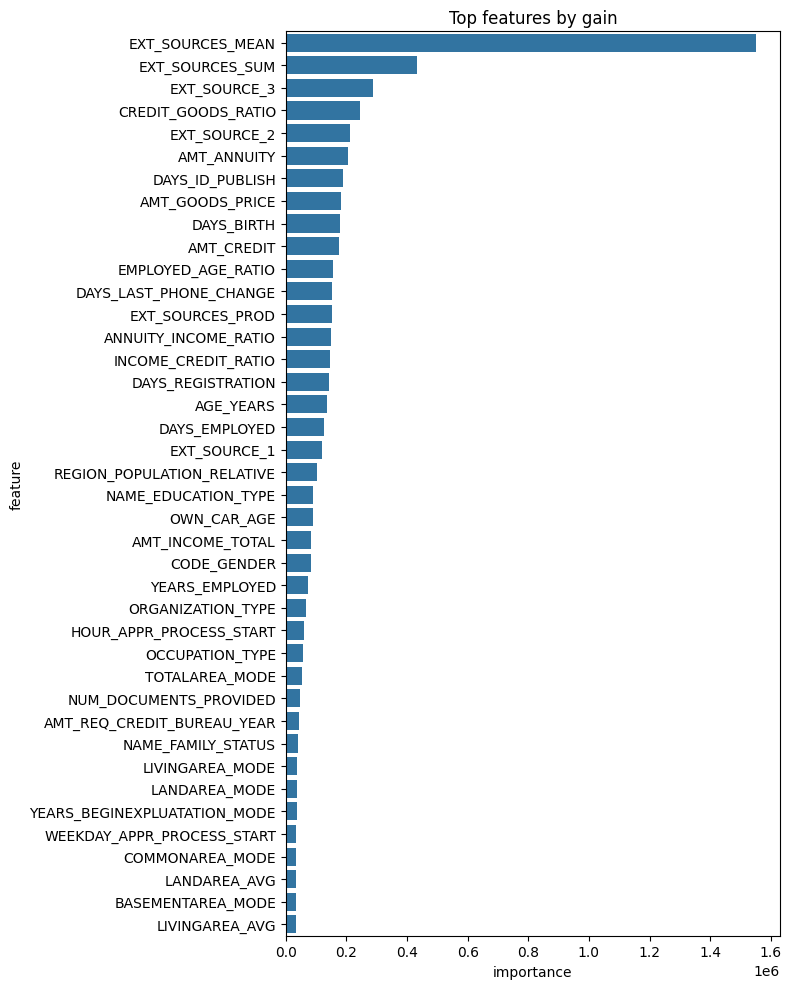

In [21]:
# Using the last trained bst from previous cell
try:
    fi = pd.DataFrame({'feature': features, 'importance': bst.feature_importance(importance_type='gain')})
    fi = fi.sort_values('importance', ascending=False).head(40)
    plt.figure(figsize=(8,10))
    sns.barplot(x='importance', y='feature', data=fi)
    plt.title('Top features by gain')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Error showing feature importance:', e)

## 9. Save submission.csv (probabilities)

In [22]:
if ('test' in globals()) and (not test.empty) and sub_preds is not None:
    
    # --- START OF MODIFICATION ---
    # Define a threshold to convert probabilities to 0s or 1s
    threshold = 0.5
    
    # Apply the threshold
    # (sub_preds > threshold) creates a True/False array
    # .astype(int) converts True to 1 and False to 0
    binary_preds = (sub_preds > threshold).astype(int)
    # --- END OF MODIFICATION ---

    if sample is not None and 'ID' in sample.columns and 'TARGET' in sample.columns:
        out = sample.copy()
        
        # --- MODIFIED LINE ---
        # Assign the binary_preds (0s/1s) instead of sub_preds (probabilities)
        out['TARGET'] = binary_preds 
        
        out.to_csv('submission.csv', index=False)
        print(f'Saved submission.csv using 0s/1s (threshold={threshold}).')
    else:
        # try to use detected id_col if present in test, otherwise create index
        id_for_out = test[id_col] if (id_col in test.columns) else np.arange(len(test))
        
        # --- MODIFIED LINE ---
        out = pd.DataFrame({ id_col if id_col is not None else 'ID': id_for_out, 'TARGET': binary_preds })
        
        out.to_csv('submission.csv', index=False)
        print(f"Saved generic submission.csv using 0s/1s (threshold={threshold})")
else:
    print('Test set not available — skipping submission save.')

Saved submission.csv using 0s/1s (threshold=0.5).


## done with f1 score of 0.30172 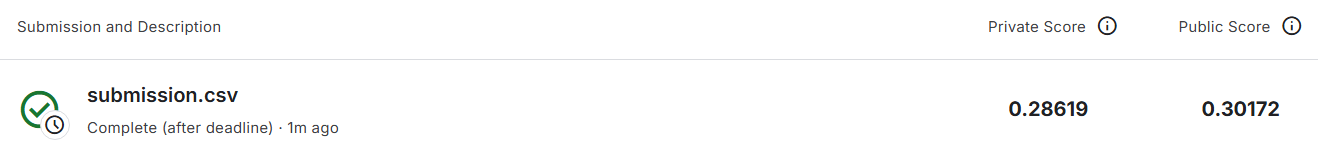